<a href="https://colab.research.google.com/github/sabithakrishnan/multimodal-image-analysis/blob/main/multimodalimage_recognition_non_linear_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install open-clip-torch datasets pillow torch torchvision matplotlib


In [2]:

import os
from pathlib import Path
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm

class ProductionDatasetBuilder:
    def __init__(self, dataset_repo: str = "blanchon/EuroSAT_RGB"):
        self.repo = dataset_repo

    def build_local_directory(self, output_dir: str = "satellite_dataset"):
        dest_path = Path(output_dir)

        # Guard clause: avoid re-running if data exists
        if dest_path.exists() and any(dest_path.iterdir()):
            print(f"📦 Workspace directory '{output_dir}' already exists. Transitioning steps...")
            return

        print(f"📡 Accessing Hugging Face native parquet tables for '{self.repo}'...")
        # Loads clean tabular shards; completely bypasses legacy python execution scripts
        dataset_split = load_dataset(self.repo, split="train")

        # Dynamically infer the land-use taxonomy from the Metadata Table schema
        label_names = dataset_split.features["label"].names
        print(f"🎯 Verified {len(label_names)} target categories for extraction.")

        print("\n💾 Unpacking and storing satellite tensors to local filesystems...")
        for idx, sample in enumerate(tqdm(dataset_split, desc="Processing Satellite Tiles")):
            pil_img = sample["image"]
            label_id = sample["label"]

            # Sanitize naming structures to eliminate runtime mapping mistakes
            class_name = label_names[label_id].replace(" ", "")

            # Map path structure: satellite_dataset/IndustrialBuildings/tile_x.jpg
            class_folder = dest_path / class_name
            class_folder.mkdir(parents=True, exist_ok=True)

            file_name = class_folder / f"tile_{idx}.jpg"

            if pil_img.mode != "RGB":
                pil_img = pil_img.convert("RGB")

            pil_img.save(file_name, "JPEG")

        print(f"\n✅ Step 2 Complete! File mapping successfully resolved inside: '{dest_path.resolve()}'")

if __name__ == "__main__":
    builder = ProductionDatasetBuilder()
    builder.build_local_directory()


📦 Workspace directory 'satellite_dataset' already exists. Transitioning steps...


📁 Processing images using ImageFolder library...
⏳ Compressing and flattening multi-dimensional pixels into vector spaces...
📝 Generating paired textual description embedding vectors...
✂️ Isolating raw image and text arrays into 80% Train and 20% Test splits...

🚀 Commencing joint multimodal backpropagation training over 15 cycles...
Epoch 01/15 | 📉 Training Loss: 1.9017 | 📈 Training Accuracy: 28.10%
Epoch 02/15 | 📉 Training Loss: 1.7275 | 📈 Training Accuracy: 37.18%
Epoch 03/15 | 📉 Training Loss: 1.7608 | 📈 Training Accuracy: 30.90%
Epoch 04/15 | 📉 Training Loss: 1.6061 | 📈 Training Accuracy: 43.11%
Epoch 05/15 | 📉 Training Loss: 1.6075 | 📈 Training Accuracy: 39.91%
Epoch 06/15 | 📉 Training Loss: 1.5863 | 📈 Training Accuracy: 43.17%
Epoch 07/15 | 📉 Training Loss: 1.5013 | 📈 Training Accuracy: 42.44%
Epoch 08/15 | 📉 Training Loss: 1.5080 | 📈 Training Accuracy: 41.45%
Epoch 09/15 | 📉 Training Loss: 1.5272 | 📈 Training Accuracy: 43.25%
Epoch 10/15 | 📉 Training Loss: 1.4074 | 📈 Training 

/tmp/ipykernel_16181/3785679567.py:234: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=f1_scores, palette="viridis")


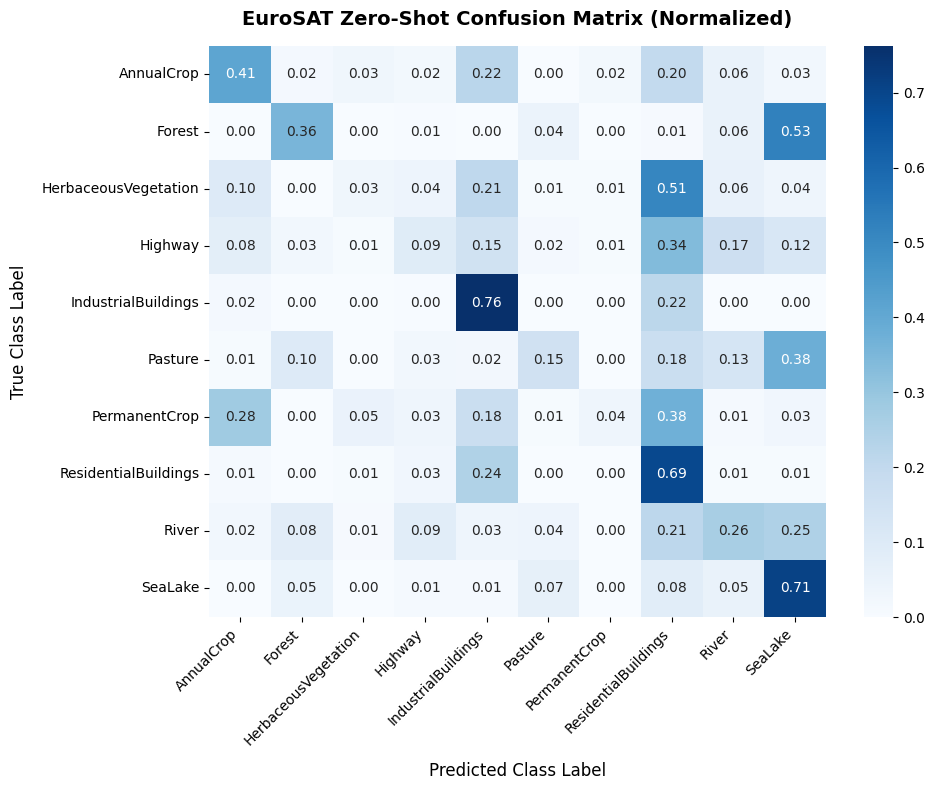

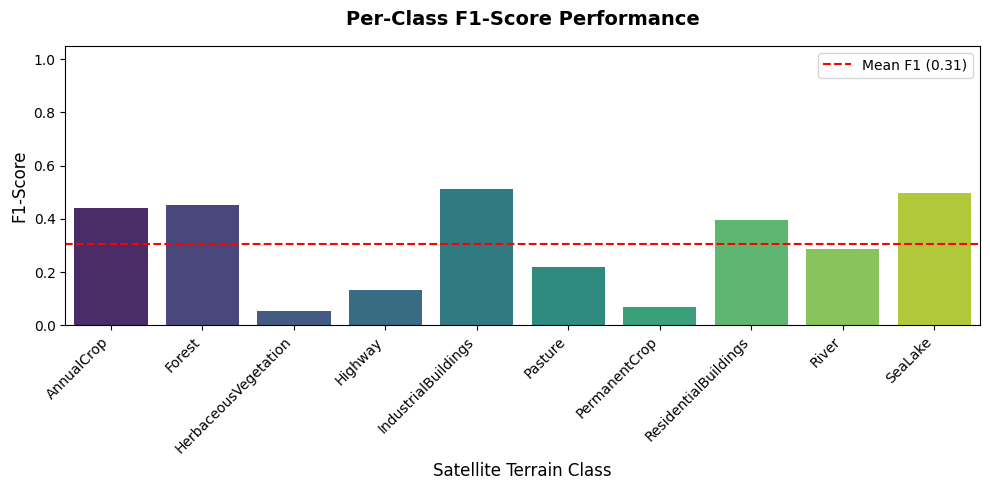

💾 F1-Score chart saved as 'per_class_f1_scores.png'


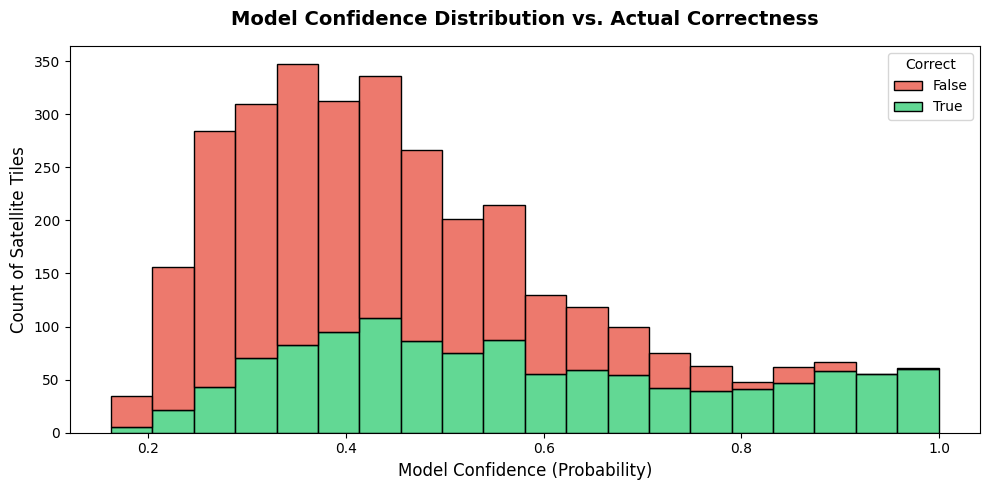

In [3]:
import os
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

#defining activation function
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

#Multimodal MLP
class MultimodalMLP:
    def __init__(self, image_dim, text_dim, hidden_dim, output_dim, learning_rate=0.01):
        self.lr = learning_rate
        combined_dim = image_dim + text_dim#combining text and image dimensions
        #first layer
        self.W1 = np.random.randn(combined_dim, hidden_dim) * np.sqrt(2.0 / combined_dim)
        self.b1 = np.zeros((1, hidden_dim))
        #second layer
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(1.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

    def forward(self, X_img, X_txt):
        """Fuses modalities and executes standard matrix multiplication passes."""
        #concatenating image and text features
        self.X_fused = np.hstack((X_img, X_txt))
        #input->hidden layer
        self.Z1 = np.dot(self.X_fused, self.W1) + self.b1
        self.A1 = relu(self.Z1)

        # hidden->output layer
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, Y_true):

        m = self.X_fused.shape[0]

        # Output Layer Gradients
        dZ2 = self.A2 - Y_true
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Hidden Layer Gradients using relu
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = np.dot(self.X_fused.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Vanilla Gradient Descent Weight Adjustments
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def compute_loss(self, Y_pred, Y_true):

        m = Y_true.shape[0]
        Y_pred = np.clip(Y_pred, 1e-15, 1.0 - 1e-15)
        return -np.sum(Y_true * np.log(Y_pred)) / m

def to_one_hot(labels, num_classes):
    one_hot = np.zeros((labels.size, num_classes))
    one_hot[np.arange(labels.size), labels.astype(int)] = 1.0
    return one_hot
#MLOps
def main():
    data_directory = "satellite_dataset"#calling dataset

    if not os.path.exists(data_directory):
        print(f"❌ Error: The directory '{data_directory}' does not exist.")
        return

    transform = transforms.Compose([transforms.ToTensor()])# transforming for easy processing and making it light for the neural network
    dataset = ImageFolder(root=data_directory, transform=transform)
    total_classes = len(dataset.classes)

    X_img = torch.stack([img for img, _ in dataset]).view(len(dataset), -1).numpy()
    Y = torch.tensor([label for _, label in dataset]).numpy()

    text_embedding_dim = 512 # Define text embedding dimension synthetically as this is toy example. in real production use the text dataset supposed to use for this model
    X_txt = np.random.randn(len(dataset), text_embedding_dim)


    # C. Split Images, Texts, and Targets together using scikit-learn

    X_img_train, X_img_test, X_txt_train, X_txt_test, Y_train, Y_test = train_test_split(
        X_img, X_txt, Y, test_size=0.2, random_state=42, stratify=Y)


    # Encode
    Y_train_encoded = to_one_hot(Y_train, total_classes)
    Y_test_encoded = to_one_hot(Y_test, total_classes)

    # Instantiate our non linear Multimodal Multi-Layer Perceptron algorithm
    image_features_dim = X_img_train.shape[1]
    mlp = MultimodalMLP(
        image_dim=image_features_dim,
        text_dim=text_embedding_dim,
        hidden_dim=256,
        output_dim=total_classes,
        learning_rate=0.01
    )

    epochs = 15
    batch_size = 64

    for epoch in range(epochs):
        indices = np.arange(X_img_train.shape[0])
        np.random.shuffle(indices)

        X_img_shuffled = X_img_train[indices]
        X_txt_shuffled = X_txt_train[indices]
        Y_train_shuffled = Y_train_encoded[indices]

        # Mini-batch matrix computation passes
        for i in range(0, X_img_train.shape[0], batch_size):
            img_batch = X_img_shuffled[i : i + batch_size]
            txt_batch = X_txt_shuffled[i : i + batch_size]
            Y_batch = Y_train_shuffled[i : i + batch_size]

            # Forward validation mapping and optimization calculations
            mlp.forward(img_batch, txt_batch)
            mlp.backward(Y_batch)

        # Performance checking
        train_predictions = mlp.forward(X_img_train, X_txt_train)
        loss = mlp.compute_loss(train_predictions, Y_train_encoded)
        train_acc = np.mean(np.argmax(train_predictions, axis=1) == Y_train) * 100
        print(f"Epoch {epoch+1:02d}/{epochs} | 📉 Training Loss: {loss:.4f} | 📈 Training Accuracy: {train_acc:.2f}%")
    test_outputs = mlp.forward(X_img_test, X_txt_test)
    test_accuracy = np.mean(np.argmax(test_outputs, axis=1) == Y_test) * 100
    print(f"🎯 Final Multimodal Verification -> Test Accuracy: {test_accuracy:.2f}%")

    # Collect predictions and true labels for detailed metrics
    all_targets = Y_test
    all_predictions = np.argmax(test_outputs, axis=1)
    all_confidences = np.max(test_outputs, axis=1)
    all_correctness = (all_predictions == all_targets)

    # Compute and normalize the matrix
    cm = confusion_matrix(all_targets, all_predictions)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    #compute classification report and extract per class F1 score
    report_dict = classification_report(all_targets, all_predictions, target_names=dataset.classes, output_dict=True)
    classes = dataset.classes
    f1_scores = [report_dict[cls]['f1-score'] for cls in classes]
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN= np.sum(cm) - (FP + FN + TP)
    total_samples = np.sum(cm)
# Adding a small epsilon (1e-7) prevents "division by zero" errors
    class_accuracy  = (TP +TN) / (TP+TN+FP+FN)
    class_precision = TP / (TP + FP + 1e-7)
    class_recall    = TP / (TP + FN + 1e-7) # Equivalent to Sensitivity
    class_f1        = 2 * (class_precision * class_recall) / (class_precision + class_recall + 1e-7)

# --- Global Macro-Averaging ---
    accuracy  = np.mean(class_accuracy)
    precision = np.mean(class_precision)
    recall    = np.mean(class_recall)
    f1        = np.mean(class_f1)
    print(f"Accuracy: {accuracy:.4f}") # Overall match
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    # Create the heatmap plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=dataset.classes,
        yticklabels=dataset.classes,
        cbar=True
    )

    plt.title("EuroSAT Zero-Shot Confusion Matrix (Normalized)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Predicted Class Label", fontsize=12, labelpad=10)
    plt.ylabel("True Class Label", fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    # Plot F1-Scores
    plt.figure(figsize=(10, 5))
    sns.barplot(x=classes, y=f1_scores, palette="viridis")
    plt.axhline(y=np.mean(f1_scores), color='r', linestyle='--', label=f'Mean F1 ({np.mean(f1_scores):.2f})')
    plt.title("Per-Class F1-Score Performance", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Satellite Terrain Class", fontsize=12)
    plt.ylabel("F1-Score", fontsize=12)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print("💾 F1-Score chart saved as 'per_class_f1_scores.png'")
    # Plot Confidence Distribution broken down by True vs False predictions
    plt.figure(figsize=(10, 5))
    df_perf = {"Confidence": all_confidences, "Correct": all_correctness}
    sns.histplot(data=df_perf, x="Confidence", hue="Correct", multiple="stack", bins=20, palette={True: "#2ecc71", False: "#e74c3c"})
    plt.title("Model Confidence Distribution vs. Actual Correctness", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Model Confidence (Probability)", fontsize=12)
    plt.ylabel("Count of Satellite Tiles", fontsize=12)
    plt.tight_layout()
    plt.show()
if __name__ == "__main__":
    main()
